# Mini Project: Stroke Prediction
## Notebook 2: Preprocessing, Modeling และ Evaluation

| ขั้นตอน | เนื้อหา | เกณฑ์คะแนนที่เกี่ยวข้อง |
|---|---|---|
| 1 | เตรียมข้อมูลและแบ่ง Train/Test | Data Preprocessing |
| 2 | Preprocessing Pipeline (Missing, Encoding, Scaling) | Data Preprocessing |
| 3 | Baseline และฟังก์ชันประเมินผล | Model Evaluation |
| 4 | จัดการ Imbalanced Data (class_weight / SMOTE / Undersample) | Data Preprocessing, Model |
| 5 | เปรียบเทียบโมเดล 3 ตัว (Logistic Regression, Decision Tree, Random Forest) + ตรวจ Overfitting | Machine Learning Model |
| 6 | Cross-Validation + GridSearch | Model, Evaluation |
| 7 | Feature Selection | Data Preprocessing |
| 8 | โมเดลสุดท้าย, Threshold, ประเมินชุด Test, Learning Curve | Model Evaluation |
| 9 | บันทึกโมเดลสำหรับ Web Application | Web Application |

## 1. เตรียมข้อมูลและแบ่ง Train/Test
### 1.1 Import และตั้งค่า

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

import os
FIG_DIR = "../report/figures"          # เก็บรูปไว้ใส่รายงาน
os.makedirs(FIG_DIR, exist_ok=True)

print("พร้อมแล้ว!")

พร้อมแล้ว!


### 1.2 ทำความสะอาดข้อมูล (ขั้นที่ไม่ต้องใช้สถิติ จึงทำก่อนแบ่งข้อมูลได้)
- ตัด `gender = Other` (1 แถว) และตัด `id`

In [2]:
df = pd.read_csv("../data/healthcare-dataset-stroke-data.csv")
print("ก่อนทำความสะอาด:", df.shape)

# 1) ตัด gender = Other (มีแค่ 1 แถว โมเดลเรียนรู้ไม่ได้)
df = df[df["gender"] != "Other"]

# 2) ตัด id (เป็นแค่รหัส ไม่มีความหมายต่อการทำนาย)
df = df.drop(columns="id")

print("หลังทำความสะอาด:", df.shape)

ก่อนทำความสะอาด: (5110, 12)
หลังทำความสะอาด: (5109, 11)


### 1.3 แบ่ง Train 80% / Test 20%
`stratify=y` ให้ทั้งสองชุดมีสัดส่วน stroke เท่ากัน, ชุด Test เก็บไว้ประเมินครั้งสุดท้ายเท่านั้น

In [3]:
X = df.drop(columns="stroke")
y = df["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, "| stroke =", y_train.sum(), f"({y_train.mean()*100:.2f}%)")
print("Test :", X_test.shape, "| stroke =", y_test.sum(), f"({y_test.mean()*100:.2f}%)")

Train: (4087, 10) | stroke = 199 (4.87%)
Test : (1022, 10) | stroke = 50 (4.89%)


## 2. Preprocessing Pipeline
| คอลัมน์ | วิธีจัดการ | เหตุผล |
|---|---|---|
| age, avg_glucose_level, bmi | เติมค่าหายด้วย median + `add_indicator` → StandardScaler | bmi หายแบบไม่สุ่ม (อัตรา stroke 19.9%), median ทนต่อ outlier |
| hypertension, heart_disease | ใช้ได้เลย (passthrough) | เป็น 0/1 อยู่แล้ว |
| คอลัมน์ข้อความ | OneHotEncoder | ไม่มีลำดับ จึงไม่ใช้ Label Encoding |

ทุกขั้น `fit` จากชุด Train เท่านั้น → ไม่มี data leakage

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ["age", "avg_glucose_level", "bmi"]
bin_cols = ["hypertension", "heart_disease"]
cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

# คอลัมน์ตัวเลข: เติมค่าหายด้วย median + เพิ่มคอลัมน์บอกว่าหาย -> แล้ว scale
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),                                # ตัวเลข -> เติม + scale
    ("bin", "passthrough", bin_cols),                           # 0/1 -> ใช้ได้เลย
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),  # ข้อความ -> one-hot
])

X_train_prep = preprocessor.fit_transform(X_train)
print("ก่อน:", X_train.shape, "-> หลัง:", X_train_prep.shape)
print(list(preprocessor.get_feature_names_out()))

ก่อน: (4087, 10) -> หลัง: (4087, 21)
['num__age', 'num__avg_glucose_level', 'num__bmi', 'num__missingindicator_bmi', 'bin__hypertension', 'bin__heart_disease', 'cat__gender_Female', 'cat__gender_Male', 'cat__ever_married_No', 'cat__ever_married_Yes', 'cat__work_type_Govt_job', 'cat__work_type_Never_worked', 'cat__work_type_Private', 'cat__work_type_Self-employed', 'cat__work_type_children', 'cat__Residence_type_Rural', 'cat__Residence_type_Urban', 'cat__smoking_status_Unknown', 'cat__smoking_status_formerly smoked', 'cat__smoking_status_never smoked', 'cat__smoking_status_smokes']


## 3. Baseline และฟังก์ชันประเมินผล
### 3.1 Baseline: ทายว่าไม่เป็นทุกคน

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

print("=== Baseline: ทายว่า 'ไม่เป็น stroke' ทุกคน ===")
print(f"Accuracy : {accuracy_score(y_test, baseline_pred):.4f}")
print(f"Recall (class 1) : {recall_score(y_test, baseline_pred):.4f}")
print("\nAccuracy สูงถึง ~95% แต่หาผู้ป่วยไม่เจอเลยแม้แต่คนเดียว")

=== Baseline: ทายว่า 'ไม่เป็น stroke' ทุกคน ===
Accuracy : 0.9511
Recall (class 1) : 0.0000

Accuracy สูงถึง ~95% แต่หาผู้ป่วยไม่เจอเลยแม้แต่คนเดียว


### 3.2 ฟังก์ชัน evaluate() (Accuracy, Precision, Recall, F1, PR-AUC)

In [6]:
from sklearn.metrics import precision_score, f1_score, average_precision_score

def evaluate(model, X_te, y_te, name):
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_te, pred),
        "Precision(1)": precision_score(y_te, pred, zero_division=0),
        "Recall(1)": recall_score(y_te, pred),
        "F1(1)": f1_score(y_te, pred),
        "PR-AUC": average_precision_score(y_te, proba),
    }

results = []
results.append(evaluate(baseline, X_test, y_test, "0. Baseline"))
pd.DataFrame(results).round(4)

,Model,Accuracy,Precision(1),Recall(1),F1(1),PR-AUC
0,0. Baseline,0.9511,0.0,0.0,0.0,0.0489


### 3.3 Logistic Regression ที่ยังไม่จัดการ imbalance

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model_naive = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000)),
])
model_naive.fit(X_train, y_train)
pred_naive = model_naive.predict(X_test)

print("=== Logistic Regression (ไม่จัดการ imbalance) ===")
print(classification_report(y_test, pred_naive, target_names=["No stroke", "Stroke"], zero_division=0))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_naive))

results.append(evaluate(model_naive, X_test, y_test, "1. Logistic (naive)"))
pd.DataFrame(results).round(4)

=== Logistic Regression (ไม่จัดการ imbalance) ===
              precision    recall  f1-score   support

   No stroke       0.95      1.00      0.97       972
      Stroke       0.50      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.73      0.51      0.51      1022
weighted avg       0.93      0.95      0.93      1022

Confusion Matrix:
 [[971   1]
 [ 49   1]]


,Model,Accuracy,Precision(1),Recall(1),F1(1),PR-AUC
0,0. Baseline,0.9511,0.0,0.00,0.0000,0.0489
1,1. Logistic (naive),0.9511,0.5,0.02,0.0385,0.2203


## 4. จัดการ Imbalanced Data
เปรียบเทียบ 3 วิธี: `class_weight="balanced"`, SMOTE, Random Undersampling
(SMOTE/Undersample อยู่ใน `imblearn` Pipeline จึงทำเฉพาะกับชุด Train)

In [8]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# --- วิธีที่ 1: class_weight='balanced' ---
model_cw = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
model_cw.fit(X_train, y_train)
results.append(evaluate(model_cw, X_test, y_test, "2. Logistic (class_weight)"))

# --- วิธีที่ 2: SMOTE oversampling ---
model_smote = ImbPipeline([
    ("prep", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000)),
])
model_smote.fit(X_train, y_train)
results.append(evaluate(model_smote, X_test, y_test, "3. Logistic (SMOTE)"))

# --- วิธีที่ 3: Random undersampling ---
model_rus = ImbPipeline([
    ("prep", preprocessor),
    ("rus", RandomUnderSampler(random_state=42)),
    ("model", LogisticRegression(max_iter=1000)),
])
model_rus.fit(X_train, y_train)
results.append(evaluate(model_rus, X_test, y_test, "4. Logistic (Undersample)"))

pd.DataFrame(results).round(4)

,Model,Accuracy,Precision(1),Recall(1),F1(1),PR-AUC
0,0. Baseline,0.9511,0.0000,0.00,0.0000,0.0489
1,1. Logistic (naive),0.9511,0.5000,0.02,0.0385,0.2203
2,2. Logistic (class_weight),0.7544,0.1423,0.80,0.2417,0.2254
3,3. Logistic (SMOTE),0.7524,0.1362,0.76,0.2310,0.2413
4,4. Logistic (Undersample),0.7192,0.1285,0.82,0.2222,0.2126


In [9]:
print("=== naive ===")
print(confusion_matrix(y_test, model_naive.predict(X_test)))
print("\n=== class_weight ===")
print(confusion_matrix(y_test, model_cw.predict(X_test)))

X_sm, y_sm = model_smote[:-1].fit_resample(X_train, y_train)
print("\nหลัง SMOTE: จำนวนแถว", X_sm.shape[0], "| class 0 =", (y_sm == 0).sum(), "| class 1 =", (y_sm == 1).sum())

=== naive ===
[[971   1]
 [ 49   1]]

=== class_weight ===
[[731 241]
 [ 10  40]]

หลัง SMOTE: จำนวนแถว 7776 | class 0 = 3888 | class 1 = 3888


## 5. เปรียบเทียบโมเดล
### 5.1 Decision Tree และ Random Forest
เปรียบเทียบกับ Logistic Regression (class_weight) จากหัวข้อ 4 รวมเป็น **3 โมเดล** ทุกตัวใช้ `class_weight` จัดการ imbalance

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "5. Decision Tree (class_weight)": Pipeline([
        ("prep", preprocessor),
        ("model", DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42)),
    ]),
    "6. Random Forest (class_weight)": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=5,
                                         class_weight="balanced_subsample", random_state=42, n_jobs=-1)),
    ]),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    results.append(evaluate(model, X_test, y_test, name))
    print("เทรนเสร็จ:", name)

pd.DataFrame(results).round(4)

เทรนเสร็จ: 5. Decision Tree (class_weight)
เทรนเสร็จ: 6. Random Forest (class_weight)


,Model,Accuracy,Precision(1),Recall(1),F1(1),PR-AUC
0,0. Baseline,0.9511,0.0000,0.00,0.0000,0.0489
1,1. Logistic (naive),0.9511,0.5000,0.02,0.0385,0.2203
2,2. Logistic (class_weight),0.7544,0.1423,0.80,0.2417,0.2254
3,3. Logistic (SMOTE),0.7524,0.1362,0.76,0.2310,0.2413
4,4. Logistic (Undersample),0.7192,0.1285,0.82,0.2222,0.2126
5,5. Decision Tree (class_weight),0.7945,0.1552,0.72,0.2553,0.1629
6,6. Random Forest (class_weight),0.8434,0.1802,0.62,0.2793,0.2065


### 5.2 ตรวจ Overfitting: ผลของ max_depth ใน Decision Tree

       max_depth  Train F1  Test F1     Gap
0              2    0.1840   0.1625  0.0215
1              3    0.1837   0.1597  0.0240
2              4    0.2400   0.2294  0.0106
3              5    0.2768   0.2553  0.0215
4              6    0.2838   0.2458  0.0380
5              8    0.3708   0.2403  0.1305
6             10    0.4408   0.2190  0.2218
7             15    0.7256   0.1630  0.5626
8  None(เต็มที่)    1.0000   0.0980  0.9020


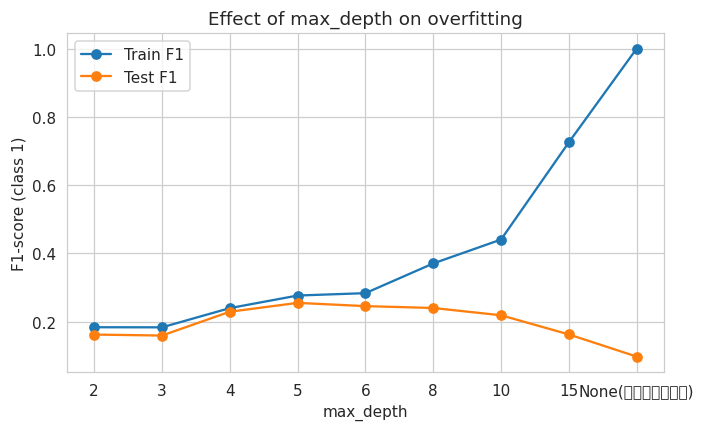

In [11]:
depths = [2, 3, 4, 5, 6, 8, 10, 15, None]
depth_results = []
for d in depths:
    t = Pipeline([
        ("prep", preprocessor),
        ("model", DecisionTreeClassifier(max_depth=d, class_weight="balanced", random_state=42)),
    ])
    t.fit(X_train, y_train)
    tr_f1 = f1_score(y_train, t.predict(X_train))
    te_f1 = f1_score(y_test, t.predict(X_test))
    depth_results.append({"max_depth": d if d else "None(เต็มที่)",
                          "Train F1": tr_f1, "Test F1": te_f1, "Gap": tr_f1 - te_f1})

df_depth = pd.DataFrame(depth_results)
display(df_depth.round(4))

plt.figure()
x_labels = [str(d) for d in df_depth["max_depth"]]
plt.plot(x_labels, df_depth["Train F1"], "o-", label="Train F1")
plt.plot(x_labels, df_depth["Test F1"], "o-", label="Test F1")
plt.xlabel("max_depth")
plt.ylabel("F1-score (class 1)")
plt.title("Effect of max_depth on overfitting")
plt.legend()
plt.savefig(f"{FIG_DIR}/06_dt_depth_overfitting.png", dpi=200, bbox_inches="tight")
plt.show()

### 5.3 Random Forest ช่วยลด Overfitting ได้ไหม

In [12]:
rf = models["6. Random Forest (class_weight)"]
rf_train_f1 = f1_score(y_train, rf.predict(X_train))
rf_test_f1 = f1_score(y_test, rf.predict(X_test))
print(f"Random Forest -> Train F1: {rf_train_f1:.4f} | Test F1: {rf_test_f1:.4f} | Gap: {rf_train_f1 - rf_test_f1:.4f}")

Random Forest -> Train F1: 0.3926 | Test F1: 0.2793 | Gap: 0.1133


## 6. Cross-Validation และ Hyperparameter Tuning
### 6.1 Stratified 5-Fold Cross-Validation (น่าเชื่อถือกว่าชุด Test ครั้งเดียว)

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"recall": "recall", "precision": "precision", "f1": "f1",
           "pr_auc": "average_precision", "roc_auc": "roc_auc"}

cv_models = {
    "Logistic (class_weight)": model_cw,
    "Decision Tree (class_weight)": models["5. Decision Tree (class_weight)"],
    "Random Forest (class_weight)": models["6. Random Forest (class_weight)"],
}

cv_rows = []
for name, model in cv_models.items():
    s = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"Model": name}
    for k in scoring:
        row[k] = f"{s['test_' + k].mean():.3f} ± {s['test_' + k].std():.3f}"
    cv_rows.append(row)
    print("CV เสร็จ:", name)

pd.DataFrame(cv_rows)

CV เสร็จ: Logistic (class_weight)
CV เสร็จ: Decision Tree (class_weight)
CV เสร็จ: Random Forest (class_weight)


,Model,recall,precision,f1,pr_auc,roc_auc
0,Logistic (class_weight),0.799 ± 0.070,0.142 ± 0.014,0.242 ± 0.024,0.225 ± 0.039,0.854 ± 0.024
1,Decision Tree (class_weight),0.779 ± 0.065,0.118 ± 0.012,0.205 ± 0.020,0.190 ± 0.029,0.790 ± 0.015
2,Random Forest (class_weight),0.517 ± 0.038,0.164 ± 0.017,0.248 ± 0.022,0.199 ± 0.031,0.830 ± 0.030


### 6.2 GridSearchCV

In [14]:
from sklearn.model_selection import GridSearchCV

# --- Logistic Regression ---
lr_grid = GridSearchCV(
    model_cw,
    param_grid={"model__C": [0.01, 0.1, 1, 10],
                "model__l1_ratio": [0, 1],          # 0 = L2 (Ridge), 1 = L1 (Lasso)
                "model__solver": ["liblinear"]},
    cv=cv, scoring="average_precision", n_jobs=-1,
)
lr_grid.fit(X_train, y_train)
print("Logistic best params:", lr_grid.best_params_)
print(f"Logistic best CV PR-AUC: {lr_grid.best_score_:.4f}")

# --- Random Forest ---
rf_grid = GridSearchCV(
    models["6. Random Forest (class_weight)"],
    param_grid={"model__max_depth": [4, 6, 8, None],
                "model__min_samples_leaf": [5, 10, 20]},
    cv=cv, scoring="average_precision", n_jobs=-1,
)
rf_grid.fit(X_train, y_train)
print("\nRandom Forest best params:", rf_grid.best_params_)
print(f"Random Forest best CV PR-AUC: {rf_grid.best_score_:.4f}")

Logistic best params: {'model__C': 0.01, 'model__l1_ratio': 1, 'model__solver': 'liblinear'}
Logistic best CV PR-AUC: 0.2329

Random Forest best params: {'model__max_depth': 8, 'model__min_samples_leaf': 20}
Random Forest best CV PR-AUC: 0.2082


### 6.3 วิเคราะห์ผล GridSearch
อันดับ 1 ใช้ฟีเจอร์แค่ 3 ตัว (ตัด hypertension, heart_disease) และคะแนนต่างจากอันดับอื่นน้อยกว่า std
→ เลือก **C=0.1, L2** ที่คะแนนอยู่ในช่วงเดียวกันแต่ยังใช้ปัจจัยทางการแพทย์ครบ

In [15]:
# ดูผล GridSearch ทุกชุด ไม่ใช่แค่อันดับ 1
grid_table = pd.DataFrame(lr_grid.cv_results_)[["param_model__C", "param_model__l1_ratio",
                                                 "mean_test_score", "std_test_score", "rank_test_score"]]
grid_table.columns = ["C", "l1_ratio", "CV PR-AUC", "std", "rank"]
display(grid_table.sort_values("rank").round(4))

# ดูว่าโมเดลอันดับ 1 ใช้ฟีเจอร์อะไรบ้าง
best_lr = lr_grid.best_estimator_
names = best_lr.named_steps["prep"].get_feature_names_out()
best_coef = pd.Series(best_lr.named_steps["model"].coef_[0], index=names)
print("อันดับ 1 (C=0.01, L1) ใช้ฟีเจอร์ที่ coef ไม่เป็น 0 แค่:", list(best_coef[best_coef != 0].index))

       C  l1_ratio  CV PR-AUC     std  rank
1   0.01         1     0.2329  0.0332     1
3   0.10         1     0.2323  0.0409     2
0   0.01         0     0.2258  0.0346     3
2   0.10         0     0.2258  0.0391     4
5   1.00         1     0.2252  0.0386     5
4   1.00         0     0.2248  0.0385     6
6  10.00         0     0.2242  0.0387     7
7  10.00         1     0.2241  0.0387     8
อันดับ 1 (C=0.01, L1) ใช้ฟีเจอร์ที่ coef ไม่เป็น 0 แค่: ['num__age', 'num__avg_glucose_level', 'num__missingindicator_bmi']


## 7. Feature Selection
ทดลองตัดฟีเจอร์ที่ EDA บอกว่าอ่อน (gender, Residence_type) และตัวแปรกวนจากอายุ (ever_married, work_type)

In [16]:
# === Feature Selection: ทดลองตัดฟีเจอร์ที่ EDA บอกว่าอ่อน แล้วเทียบด้วย 5-fold CV ===
def build_model(features):
    """สร้าง Pipeline (preprocessing + Logistic Regression) จากรายชื่อฟีเจอร์ที่เลือก"""
    num = [c for c in num_cols if c in features]
    bina = [c for c in bin_cols if c in features]
    cat = [c for c in cat_cols if c in features]
    prep = ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                          ("scaler", StandardScaler())]), num),
        ("bin", "passthrough", bina),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
    ])
    return Pipeline([
        ("prep", prep),
        ("model", LogisticRegression(C=0.1, l1_ratio=0, solver="liblinear",
                                     class_weight="balanced", max_iter=1000)),
    ])

all_features = list(X.columns)
feature_sets = {
    "A. ใช้ทั้ง 10 ฟีเจอร์": all_features,
    "B. ตัด gender, Residence_type": [f for f in all_features if f not in ["gender", "Residence_type"]],
    "C. B + ตัด ever_married, work_type": [f for f in all_features
                                           if f not in ["gender", "Residence_type", "ever_married", "work_type"]],
    "D. อายุอย่างเดียว": ["age"],
}

fs_rows = []
for name, feats in feature_sets.items():
    s = cross_validate(build_model(feats), X_train[feats], y_train, cv=cv,
                       scoring={"recall": "recall", "f1": "f1", "pr_auc": "average_precision", "roc_auc": "roc_auc"})
    fs_rows.append({"Feature set": name, "จำนวนฟีเจอร์": len(feats),
                    **{k: f"{s['test_' + k].mean():.3f} ± {s['test_' + k].std():.3f}"
                       for k in ["recall", "f1", "pr_auc", "roc_auc"]}})
display(pd.DataFrame(fs_rows))

print("ชุด C (6 ฟีเจอร์) ได้คะแนนเท่ากับชุด A (10 ฟีเจอร์) ในช่วงความแกว่ง (std)")
print("   -> เลือกชุด C: โมเดลเรียบง่ายกว่า ตัดตัวแปรกวน (ever_married, work_type) และฟอร์มบนเว็บสั้นลง")
print("   ชุด D (อายุอย่างเดียว) PR-AUC ตกชัดเจน -> ฟีเจอร์อื่นยังจำเป็น")

                          Feature set  จำนวนฟีเจอร์         recall             f1         pr_auc        roc_auc
0               A. ใช้ทั้ง 10 ฟีเจอร์            10  0.799 ± 0.065  0.240 ± 0.023  0.226 ± 0.039  0.854 ± 0.024
1       B. ตัด gender, Residence_type             8  0.794 ± 0.057  0.237 ± 0.020  0.230 ± 0.040  0.856 ± 0.025
2  C. B + ตัด ever_married, work_type             6  0.799 ± 0.052  0.235 ± 0.017  0.228 ± 0.037  0.856 ± 0.024
3                   D. อายุอย่างเดียว             1  0.809 ± 0.090  0.221 ± 0.028  0.166 ± 0.016  0.834 ± 0.025
ชุด C (6 ฟีเจอร์) ได้คะแนนเท่ากับชุด A (10 ฟีเจอร์) ในช่วงความแกว่ง (std)
   -> เลือกชุด C: โมเดลเรียบง่ายกว่า ตัดตัวแปรกวน (ever_married, work_type) และฟอร์มบนเว็บสั้นลง
   ชุด D (อายุอย่างเดียว) PR-AUC ตกชัดเจน -> ฟีเจอร์อื่นยังจำเป็น


## 8. โมเดลสุดท้ายและการประเมินผล
### 8.1 โมเดลสุดท้าย + Coefficients

**เหตุผลที่เลือก Logistic Regression:** Recall ใน CV สูงสุด (0.80), PR-AUC/ROC-AUC สูงสุด, std ต่ำ,
อธิบายได้ด้วย coefficient และให้คะแนนความน่าจะเป็นที่ต่อเนื่องสำหรับแสดงบนเว็บ

ฟีเจอร์ที่ใช้: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'smoking_status']


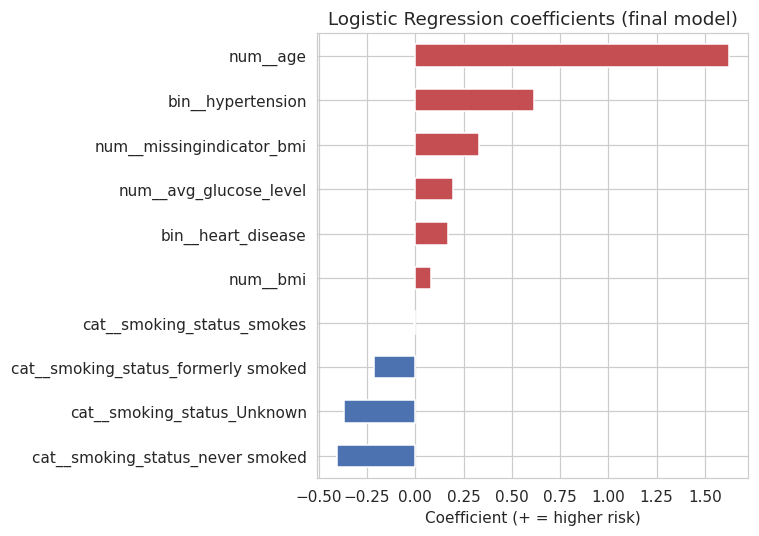

In [17]:
# === โมเดลสุดท้าย: Logistic Regression (C=0.1, L2, class_weight) + ฟีเจอร์ชุด C ===
FINAL_FEATURES = feature_sets["C. B + ตัด ever_married, work_type"]
print("ฟีเจอร์ที่ใช้:", FINAL_FEATURES)

final_model = build_model(FINAL_FEATURES)
final_model.fit(X_train[FINAL_FEATURES], y_train)

names = final_model.named_steps["prep"].get_feature_names_out()
coef = pd.Series(final_model.named_steps["model"].coef_[0], index=names).sort_values()
plt.figure(figsize=(7, 5))
coef.plot(kind="barh", color=["#C44E52" if c > 0 else "#4C72B0" for c in coef])
plt.title("Logistic Regression coefficients (final model)")
plt.xlabel("Coefficient (+ = higher risk)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_final_coefficients.png", dpi=200, bbox_inches="tight")
plt.show()

### 8.2 เลือก Threshold จาก Cross-Validation
เป้าหมาย Recall ≥ 0.80 เพราะงานคัดกรอง False Negative (พลาดผู้ป่วยจริง) อันตรายกว่า False Positive

In [18]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

# ความน่าจะเป็นแบบ out-of-fold: แต่ละแถวถูกทำนายโดยโมเดลที่ไม่เคยเห็นแถวนั้น
oof_proba = cross_val_predict(final_model, X_train[FINAL_FEATURES], y_train, cv=cv, method="predict_proba")[:, 1]

prec, rec, thr = precision_recall_curve(y_train, oof_proba)
thr_table = pd.DataFrame({"threshold": thr, "precision": prec[:-1], "recall": rec[:-1]})

TARGET_RECALL = 0.80   # เป้าหมาย: จับผู้ป่วยได้อย่างน้อย 80%
THRESHOLD = np.floor(thr_table.loc[thr_table["recall"] >= TARGET_RECALL, "threshold"].max() * 100) / 100
print(f"Threshold ที่เลือก = {THRESHOLD}\n")

for t in [0.3, 0.4, THRESHOLD, 0.6, 0.7]:
    p = (oof_proba >= t).astype(int)
    print(f"threshold {t:.2f} -> Recall {recall_score(y_train, p):.3f} | "
          f"Precision {precision_score(y_train, p):.3f} | ทายว่าเสี่ยง {p.sum()} คน")

Threshold ที่เลือก = 0.49

threshold 0.30 -> Recall 0.940 | Precision 0.102 | ทายว่าเสี่ยง 1830 คน
threshold 0.40 -> Recall 0.879 | Precision 0.120 | ทายว่าเสี่ยง 1463 คน
threshold 0.49 -> Recall 0.814 | Precision 0.137 | ทายว่าเสี่ยง 1183 คน
threshold 0.60 -> Recall 0.709 | Precision 0.158 | ทายว่าเสี่ยง 893 คน
threshold 0.70 -> Recall 0.623 | Precision 0.192 | ทายว่าเสี่ยง 647 คน


### 8.3 ประเมินผลบนชุด Test (ครั้งเดียว)

=== Final model on TEST set (threshold = 0.49) ===
              precision    recall  f1-score   support

   No stroke      0.988     0.739     0.845       972
      Stroke      0.139     0.820     0.238        50

    accuracy                          0.743      1022
   macro avg      0.563     0.779     0.541      1022
weighted avg      0.946     0.743     0.815      1022

PR-AUC : 0.2122
ROC-AUC: 0.8360


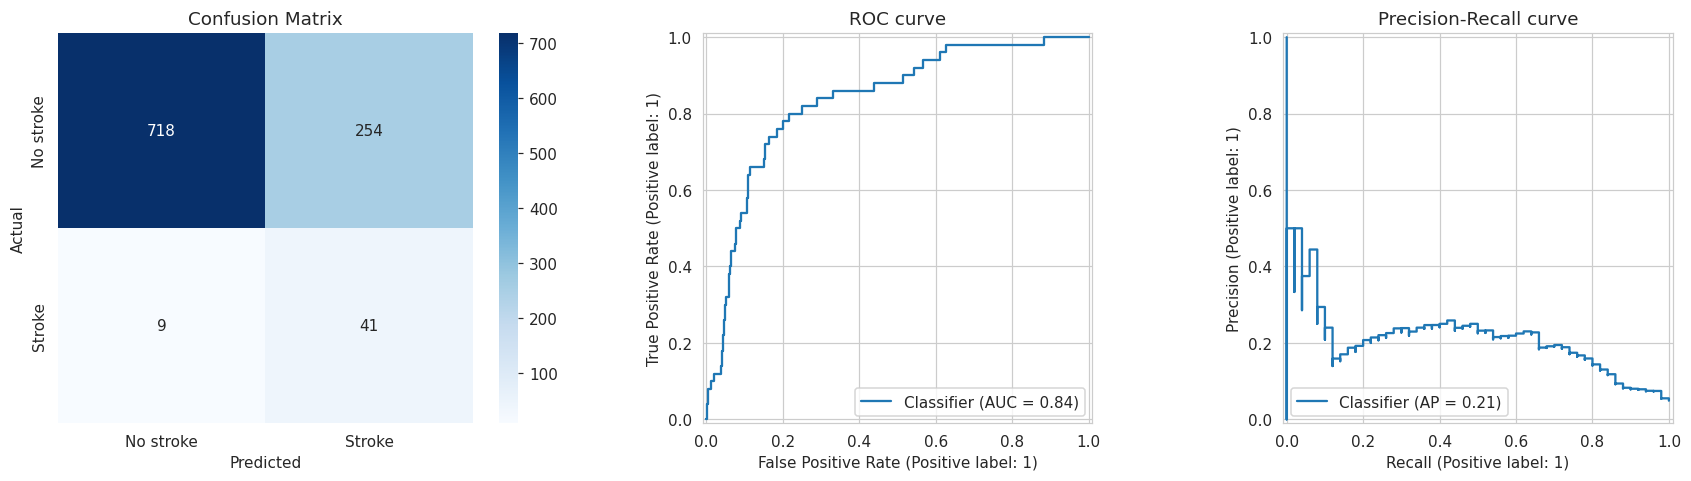

In [19]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay

proba_test = final_model.predict_proba(X_test[FINAL_FEATURES])[:, 1]
pred_test = (proba_test >= THRESHOLD).astype(int)

print(f"=== Final model on TEST set (threshold = {THRESHOLD}) ===")
print(classification_report(y_test, pred_test, target_names=["No stroke", "Stroke"], digits=3))
print(f"PR-AUC : {average_precision_score(y_test, proba_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, proba_test):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.heatmap(confusion_matrix(y_test, pred_test), annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No stroke", "Stroke"], yticklabels=["No stroke", "Stroke"])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual"); axes[0].set_title("Confusion Matrix")
RocCurveDisplay.from_predictions(y_test, proba_test, ax=axes[1]); axes[1].set_title("ROC curve")
PrecisionRecallDisplay.from_predictions(y_test, proba_test, ax=axes[2]); axes[2].set_title("Precision-Recall curve")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/08_final_test_evaluation.png", dpi=200, bbox_inches="tight")
plt.show()

### 8.4 Learning Curve

เส้น Train กับ Validation ลู่เข้าหากันที่ประมาณ 0.23 -> ไม่มี overfitting
   แต่คะแนนยังต่ำทั้งคู่ -> ข้อจำกัดอยู่ที่ข้อมูล (ฟีเจอร์มีน้อย, ผู้ป่วยน้อย) มากกว่าตัวโมเดล


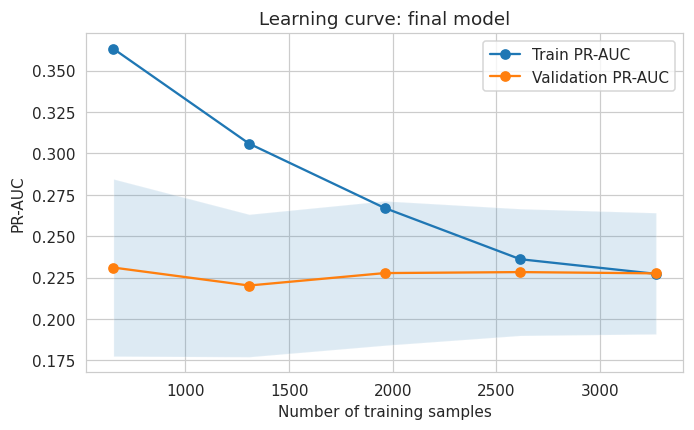

In [20]:
# === Learning Curve ของโมเดลสุดท้าย (ตรวจ overfitting แบบในตัวอย่างอาจารย์) ===
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    build_model(FINAL_FEATURES), X_train[FINAL_FEATURES], y_train, cv=cv,
    scoring="average_precision", train_sizes=np.linspace(0.2, 1.0, 5), n_jobs=-1,
)
plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Train PR-AUC")
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Validation PR-AUC")
plt.fill_between(train_sizes, val_scores.mean(1) - val_scores.std(1),
                 val_scores.mean(1) + val_scores.std(1), alpha=0.15)
plt.xlabel("Number of training samples")
plt.ylabel("PR-AUC")
plt.title("Learning curve: final model")
plt.legend()
plt.savefig(f"{FIG_DIR}/09_learning_curve.png", dpi=200, bbox_inches="tight")
plt.show()

print("เส้น Train กับ Validation ลู่เข้าหากันที่ประมาณ 0.23 -> ไม่มี overfitting")
print("   แต่คะแนนยังต่ำทั้งคู่ -> ข้อจำกัดอยู่ที่ข้อมูล (ฟีเจอร์มีน้อย, ผู้ป่วยน้อย) มากกว่าตัวโมเดล")

## 9. บันทึกโมเดลสำหรับ Web Application

In [21]:
import joblib, sklearn, os

os.makedirs("../models", exist_ok=True)
bundle = {
    "model": final_model,                 # Pipeline ทั้งก้อน (preprocessing + โมเดล)
    "threshold": THRESHOLD,
    "features": FINAL_FEATURES,
    "sklearn_version": sklearn.__version__,
}
joblib.dump(bundle, "../models/stroke_model.joblib")
print("บันทึกแล้ว: models/stroke_model.joblib")

# ทดสอบโหลดกลับมา แล้วทำนายข้อมูลดิบ 1 คน (แบบที่เว็บจะส่งมา)
loaded = joblib.load("../models/stroke_model.joblib")
sample = pd.DataFrame([{
    "age": 67, "hypertension": 0, "heart_disease": 1,
    "avg_glucose_level": 228.69, "bmi": 36.6, "smoking_status": "formerly smoked",
}])
p = loaded["model"].predict_proba(sample)[0, 1]
print(f"คะแนนความเสี่ยง = {p:.2f} -> {'เสี่ยง' if p >= loaded['threshold'] else 'ไม่เสี่ยง'}")

บันทึกแล้ว: models/stroke_model.joblib
คะแนนความเสี่ยง = 0.77 -> เสี่ยง


## 10. สรุปผลทุกโมเดล

                                   Model  Accuracy  Precision(1)  Recall(1)   F1(1)  PR-AUC
0                            0. Baseline    0.9511        0.0000       0.00  0.0000  0.0489
1                    1. Logistic (naive)    0.9511        0.5000       0.02  0.0385  0.2203
2             2. Logistic (class_weight)    0.7544        0.1423       0.80  0.2417  0.2254
3                    3. Logistic (SMOTE)    0.7524        0.1362       0.76  0.2310  0.2413
4              4. Logistic (Undersample)    0.7192        0.1285       0.82  0.2222  0.2126
5        5. Decision Tree (class_weight)    0.7945        0.1552       0.72  0.2553  0.1629
6        6. Random Forest (class_weight)    0.8434        0.1802       0.62  0.2793  0.2065
7  ★ Final: Logistic (C=0.1, 6 features)    0.7427        0.1390       0.82  0.2377  0.2122


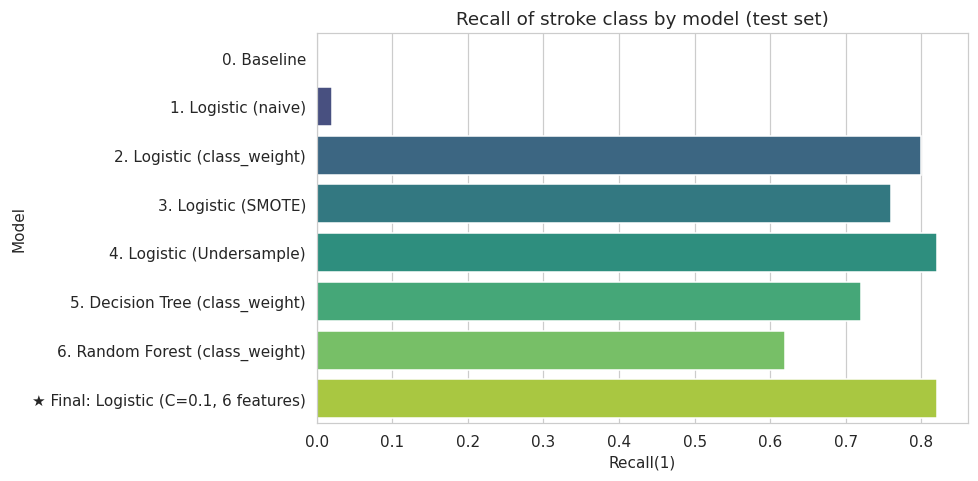

In [22]:
# === สรุปผลทุกโมเดล (ชุด test) + โมเดลสุดท้าย ===
final_row = evaluate(final_model, X_test[FINAL_FEATURES], y_test, "★ Final: Logistic (C=0.1, 6 features)")
final_pred = (final_model.predict_proba(X_test[FINAL_FEATURES])[:, 1] >= THRESHOLD).astype(int)
final_row.update({                      # ใช้ threshold ของเรา แทน 0.5
    "Accuracy": accuracy_score(y_test, final_pred),
    "Precision(1)": precision_score(y_test, final_pred),
    "Recall(1)": recall_score(y_test, final_pred),
    "F1(1)": f1_score(y_test, final_pred),
})
summary = pd.DataFrame(results + [final_row]).round(4)
display(summary)

plt.figure(figsize=(9, 4.5))
sns.barplot(data=summary, x="Recall(1)", y="Model", hue="Model", palette="viridis", legend=False)
plt.title("Recall of stroke class by model (test set)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/10_recall_by_model.png", dpi=200, bbox_inches="tight")
plt.show()